In [1]:
import sys
import os

# Add the root thesis folder path to sys.path 
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from models import pose_hrnet
from hrnet_config import cfg , update_config
from HRNet_experiments.HRNet_finetuned.surgpose_dataset import SurgPoseDataset
import torch
import numpy as np
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from core.inference import get_max_preds
from tqdm import tqdm

In [3]:

def get_device():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    return device


In [4]:
org_h, org_w= 986,1400

In [5]:
# for HRNET 704*512
joints = 14
device = get_device()
in_height, in_width= 512,704
H_h, W_h= 128,176
sigma=5

In [6]:
def get_loader(in_height, in_width, H_h, W_h, sigma):
    data_root= '/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted_left_right'
    frames_dir= os.path.join(data_root,'extracted_frames')
    keypoints_dir= os.path.join(data_root,'extracted_keypoints')

    train_transforms= None 
    dataset = SurgPoseDataset(frames_dir,keypoints_dir, input_size=(in_width,in_height), heatmap_size=(W_h,H_h),transform=train_transforms,sigma=sigma, keep_kpt_gt= True)
    loader= DataLoader(dataset, batch_size=32,shuffle=False)
    return loader 

In [7]:
def get_gt_loss(loader,device, org_h, org_w, W_h, H_h):
    losses=[]

    for batch in tqdm(loader):
        images, targets, weights, kpts= batch
        targets= targets.to(device)
     
        kpts = kpts.to(device)
     
        kpts_from_hm, maxvals = get_max_preds(targets.cpu().numpy() )
        kpts_from_hm[...,0]= kpts_from_hm[...,0] *org_w/W_h
        kpts_from_hm[...,1]= kpts_from_hm[...,1] *org_h/H_h
        gt_kpts_np = kpts[..., :2].cpu().numpy()
   
       
        dist= np.linalg.norm(gt_kpts_np - kpts_from_hm,axis=2)
        losses.append(dist)
        
    return np.concatenate(losses, axis=0)



In [12]:
def get_gt_loss_subpixel_refinment(loader, device, org_h, org_w, W_h, H_h):
    losses = []
    scale_x = org_w / W_h
    scale_y = org_h / H_h

    for batch in tqdm(loader):
        images, targets, weights, joints_gt = batch
        
        # A. Get raw integer coordinates
        coords, maxvals = get_max_preds(targets.cpu().numpy())
        
        # B. Apply the HRNet Sub-pixel Refinement (The part you sent)
        for n in range(coords.shape[0]):
            for p in range(coords.shape[1]):
                hm = targets[n][p].cpu().numpy()
                px = int(np.floor(coords[n][p][0] + 0.5))
                py = int(np.floor(coords[n][p][1] + 0.5))
                
                if 1 < px < W_h-1 and 1 < py < H_h-1:
                    diff = np.array([
                        hm[py][px+1] - hm[py][px-1],
                        hm[py+1][px] - hm[py-1][px]
                    ])
                    coords[n][p] += np.sign(diff) * .25

        # C. Transform back to original resolution
        coords[..., 0] *= scale_x
        coords[..., 1] *= scale_y

        # D. Calculate Loss against original GT
        gt_kpts_np = joints_gt.cpu().numpy()[..., :2]
        # mask = joints_gt[..., 2].cpu().numpy() > 0 
        
        dist = np.linalg.norm(gt_kpts_np - coords, axis=2)
        # losses.append(dist[mask])
        losses.append(dist)
    return np.concatenate(losses)

In [8]:
loader1= get_loader(in_height, in_width, H_h, W_h, sigma)

In [9]:

losses1= get_gt_loss(loader1,device, org_h, org_w, W_h, H_h)

100%|██████████| 355/355 [05:20<00:00,  1.11it/s]


In [19]:
print(f'mean: {np.mean(losses1)}')
print(f'median: {np.median(losses1)}')
print(f'std: {np.std(losses1)}')
print(f'min: {np.min(losses1)}')
print(f'max: {np.max(losses1)}')

mean: 5.243321418762207
median: 5.789211273193359
std: 2.8765618801116943
min: 0.0
max: 11.043855667114258


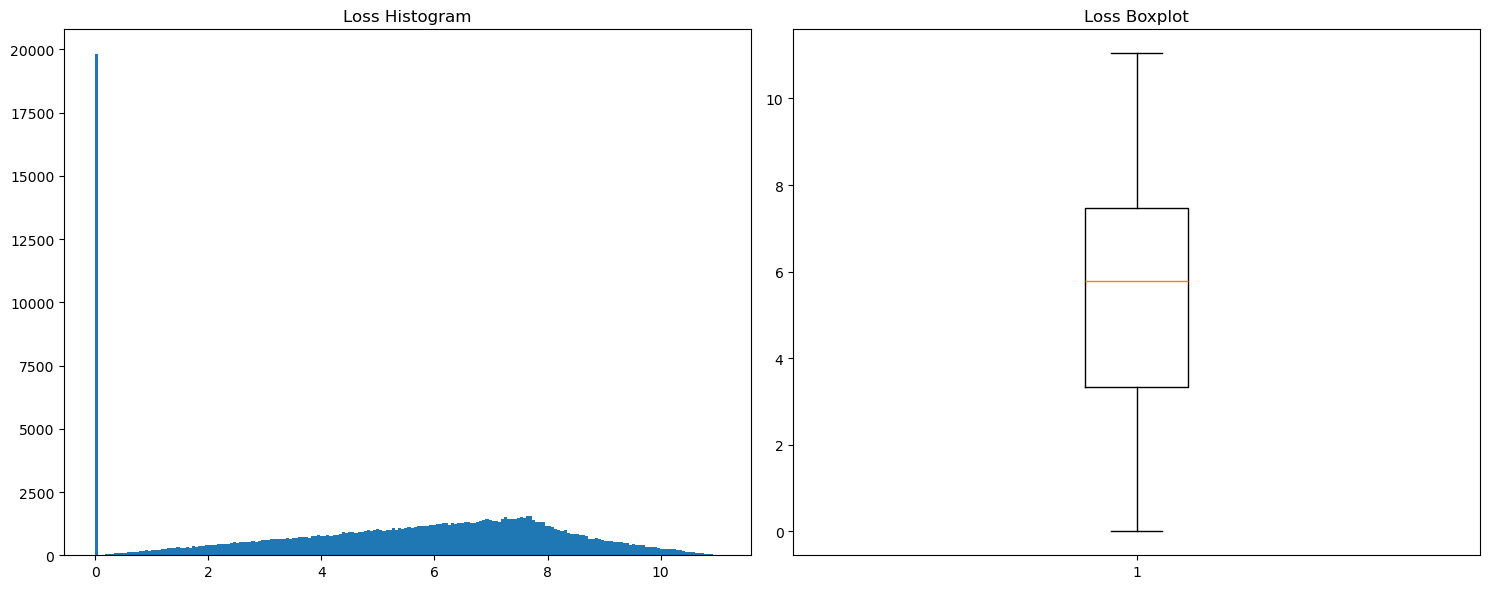

In [37]:
import matplotlib.pyplot as plt

fig,axes=plt.subplots(1,2, figsize=(15, 6))
axes[0].hist(losses1.flatten(), bins=200)
axes[0].set_title('Loss Histogram')
axes[1].boxplot(losses1.flatten(), showfliers=True)
axes[1].set_title('Loss Boxplot')
plt.tight_layout()
plt.show()

In [13]:
losses1_subpixel= get_gt_loss_subpixel_refinment(loader1,device, org_h, org_w, W_h, H_h)

100%|██████████| 355/355 [05:25<00:00,  1.09it/s]


In [14]:
np.mean(losses1_subpixel)

5.2433186

In [11]:
# for HRNET 256*192
joints = 14
device = get_device()
in_height2, in_width2= 192,256
H_h2, W_h2= 48,64
sigma2=2

In [12]:
loader2= get_loader(in_height2, in_width2, H_h2, W_h2, sigma2)

In [13]:

losses2= get_gt_loss(loader2,device, org_h, org_w, W_h2, H_h2)

100%|██████████| 355/355 [03:53<00:00,  1.52it/s]


In [39]:
print(f'mean: {np.mean(losses2)}')
print(f'median: {np.median(losses2)}')
print(f'std: {np.std(losses2)}')
print(f'min: {np.min(losses2)}')
print(f'max: {np.max(losses2)}')

mean: 14.181662559509277
median: 15.618942260742188
std: 7.795971393585205
min: 0.0
max: 29.89718246459961


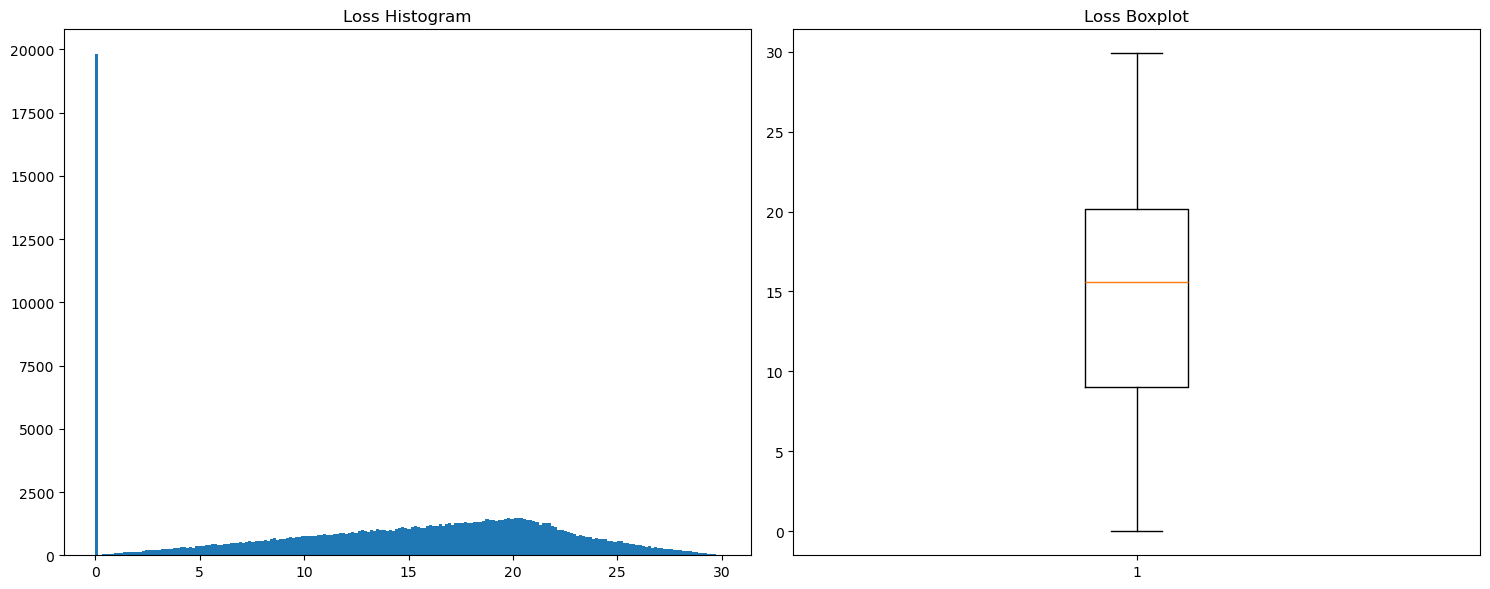

In [38]:
import matplotlib.pyplot as plt

fig,axes=plt.subplots(1,2, figsize=(15, 6))
axes[0].hist(losses2.flatten(), bins=200)
axes[0].set_title('Loss Histogram')
axes[1].boxplot(losses2.flatten(), showfliers=True)
axes[1].set_title('Loss Boxplot')
plt.tight_layout()
plt.show()

In [17]:
losses2_subpixel= get_gt_loss_subpixel_refinment(loader2,device, org_h, org_w, W_h2, H_h2)

100%|██████████| 355/355 [04:09<00:00,  1.42it/s]


In [18]:
np.mean(losses2_subpixel)

14.181671